# Clustering Model

Goal:

- To see if there are distinct expert profiles that form patterns within the survey responses.

Considerations:

- Features are the same 11 sub-indices as regression/classification 
- StandardScaler required before distance-based algorithms (index variances range 13-25).
- PCA for visualisation 
- Comparing K-Means and HDBSCAN
- Profiling will use metadata (Political Scale, Candidate Supported, demographics, PEI) to interpret clusters

## Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, HDBSCAN  
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load data

df = pd.read_csv('data/survey.csv')

role_cols = ['Politician', 'Candidate', 'Activist', 'Monitor', 'Election Official', 'Voter', 'Citizen']
df[role_cols] = df[role_cols].fillna(0)

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (726, 85)


,Election Year,Expert ID,State,Sex,Age Range,Politician,Candidate,Activist,Monitor,Election Official,...,Electoral Authorities Index,Election Rigged,Deadlines Restrictive,Voters Waited,Voters Intimidated,Multiple Ballots Cast,Machines Accurate,Records Secure,Votes Counted Quickly,Outcome Reflected Popular Will
0,2016,1,Alabama,Male,50-59,0.0,0.0,0.0,0.0,0.0,...,68.75,Disagree,Disagree,Strongly Agree,Don't Know,Don't Know,Agree,Don't Know,Agree,Disagree
1,2016,2,Alabama,Male,60-69,0.0,0.0,0.0,0.0,0.0,...,56.25,Strongly Disagree,Agree,Neither Agree Nor Disagree,Neither Agree Nor Disagree,Strongly Disagree,Agree,Don't Know,Agree,Agree
2,2016,3,Alabama,Male,60-69,0.0,0.0,0.0,0.0,0.0,...,62.50,Disagree,Disagree,Agree,Disagree,Don't Know,Neither Agree Nor Disagree,Neither Agree Nor Disagree,Strongly Agree,Neither Agree Nor Disagree
3,2016,4,Alabama,Male,50-59,0.0,0.0,0.0,0.0,0.0,...,75.00,Disagree,Strongly Agree,Strongly Agree,Don't Know,Disagree,Agree,Agree,Agree,Strongly Disagree
4,2016,5,Alabama,Male,40-49,0.0,0.0,0.0,0.0,0.0,...,74.06,Disagree,Disagree,Disagree,Disagree,Strongly Disagree,Agree,Agree,Strongly Agree,Strongly Agree


## Preprocessing

- The feature set includes the 11 sub-index columns (0-100 composite scores)

- Missing values are dealt with using median imputation as there is less than 5% missingness on any index column

- Scaling: StandardScaler before K-Means and HDBSCAN

- Metadata retained in `cluster_df` for profiling but excluded from feature matrix 'X'

In [3]:
index_cols = [
    'Electoral Laws Index', 'Election Procedures Index',
    'Voting District Boundaries Index', 'Voter Registration Index',
    'Party/Candidate Registration Index', 'Media Coverage Index',
    'Campaign Finance Index', 'Voting Process Index',
    'Vote Count Index', 'Election Results Index',
    'Electoral Authorities Index'
]

meta_cols = [
    'State', 'Sex', 'Age Range', 'Political Scale',
    'Candidate Supported', 'Perceptions of Electoral Integrity Index'
]

cluster_df = df[index_cols + meta_cols].copy()

imputer = SimpleImputer(strategy='median')
cluster_df[index_cols] = imputer.fit_transform(cluster_df[index_cols])

scaler = StandardScaler()
X = scaler.fit_transform(cluster_df[index_cols])

print(f'Feature matrix: {X.shape[0]} rows x {X.shape[1]} features')
print(f'Missing values remaining: {pd.DataFrame(X).isna().sum().sum()}')
print(f'\nFeature standard deviations (pre-scaling):')
print(cluster_df[index_cols].std().sort_values(ascending=False).round(2))

Feature matrix: 726 rows x 11 features
Missing values remaining: 0

Feature standard deviations (pre-scaling):
Electoral Laws Index                  25.00
Voting District Boundaries Index      24.94
Electoral Authorities Index           18.77
Election Procedures Index             18.35
Campaign Finance Index                17.84
Party/Candidate Registration Index    17.56
Media Coverage Index                  17.09
Voter Registration Index              16.10
Vote Count Index                      12.34
Election Results Index                12.08
Voting Process Index                  11.54
dtype: float64


Median imputation handled all missingness without dropping a single expert.

The two highest variance features (Electoral Laws and Voting District Boundaries) capture the most polarising topics in the dataset. Gerrymandering and electoral law reform are politically charged; some experts rate them near 0 but others near 100. They're most likely to drive cluster separation.

Low variance features (Vote Count, Voting Process, Election Results) confirm the EDA findings (experts broadly agreed that the mechanics of voting were conducted reasonably well). There isn't enough spread here to create meaningful cluster differentiation on these dimensions.

The 2x gap between the highest and lowest features (25.0 vs 11.54) proves why StandardScaler is necessary.

## K selection

Tracking three metrics across k = 2-10:

- Elbow (inertia/WCSS): look for the bend where adding another cluster yields diminishing returns
- Silhouette score: how similar a point is to its own cluster vs neighbours. Range -1 to 1, higher is better
- Davies-Bouldin index: ratio of within-cluster scatter to between-cluster separation, lower is better

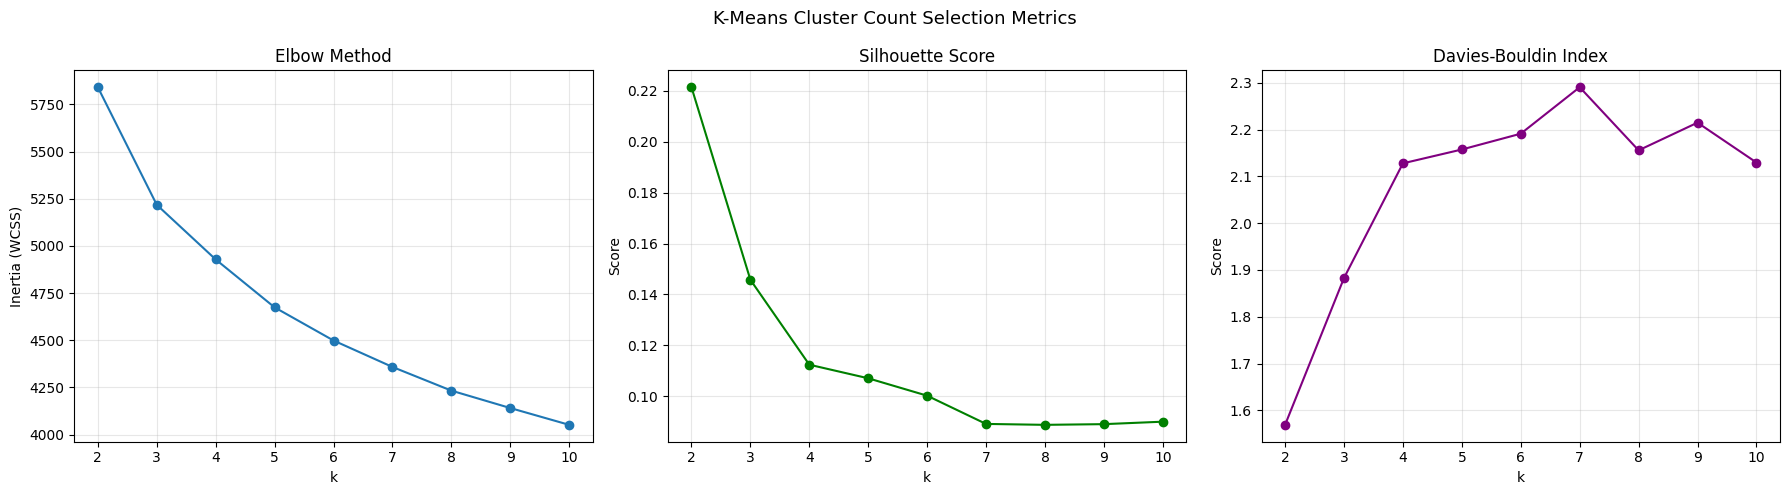

 k  Inertia  Silhouette  Davies-Bouldin
 2  5841.08      0.2213          1.5690
 3  5217.80      0.1458          1.8829
 4  4928.10      0.1125          2.1280
 5  4674.18      0.1071          2.1576
 6  4498.48      0.1003          2.1914
 7  4358.32      0.0892          2.2907
 8  4232.83      0.0889          2.1558
 9  4140.57      0.0891          2.2150
10  4051.46      0.0901          2.1298


In [4]:
k_range = range(2, 11)
inertias, sil_scores, db_scores = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    db_scores.append(davies_bouldin_score(X, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), sil_scores, marker='o', color='green')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')
axes[1].grid(True, alpha=0.3)

axes[2].plot(list(k_range), db_scores, marker='o', color='purple')
axes[2].set_title('Davies-Bouldin Index')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Score')
axes[2].grid(True, alpha=0.3)

plt.suptitle('K-Means Cluster Count Selection Metrics', fontsize=13)
plt.tight_layout()
plt.show()

scores_df = pd.DataFrame({
    'k': list(k_range),
    'Inertia': [round(i, 2) for i in inertias],
    'Silhouette': [round(s, 4) for s in sil_scores],
    'Davies-Bouldin': [round(d, 4) for d in db_scores]
})
print(scores_df.to_string(index=False))


All three metrics agree k=2

In [5]:
# Select optimal k 

best_k_sil = list(k_range)[sil_scores.index(max(sil_scores))]
best_k_db  = list(k_range)[db_scores.index(min(db_scores))]

print(f'Best k by silhouette:     {best_k_sil} (score={max(sil_scores):.4f})')
print(f'Best k by Davies-Bouldin: {best_k_db} (score={min(db_scores):.4f})')

best_k = best_k_sil if best_k_sil == best_k_db else min(best_k_sil, best_k_db)
print(f'\nSelected k = {best_k}')

Best k by silhouette:     2 (score=0.2213)
Best k by Davies-Bouldin: 2 (score=1.5690)

Selected k = 2


## K-Means Clustering

In [6]:
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = km.fit_predict(X)
cluster_df['KMeans_Cluster'] = km_labels

km_sil = silhouette_score(X, km_labels)
km_db  = davies_bouldin_score(X, km_labels)

print(f'K-Means (k={best_k})')
print(f'  Silhouette Score:  {km_sil:.4f}')
print(f'  Davies-Bouldin:    {km_db:.4f}')
print(f'  Inertia:           {km.inertia_:.2f}')
print(f'\nCluster sizes:')
print(cluster_df['KMeans_Cluster'].value_counts().sort_index())

K-Means (k=2)
  Silhouette Score:  0.2213
  Davies-Bouldin:    1.5690
  Inertia:           5841.08

Cluster sizes:
KMeans_Cluster
0    355
1    371
Name: count, dtype: int64


## HDBSCAN 

- `min_cluster_size`: minimum number of points required to form a cluster. 

- `min_samples=5` controls conservativeness 

- Silhouette is computed on non-noise points only. Noise proportion is reported alongside to assess how much of the sample is being discarded.


In [8]:
# Parameter search

min_sizes = [15, 20, 25, 30, 40, 50]
hdb_results = []

for mcs in min_sizes:
    hdb = HDBSCAN(min_cluster_size=mcs, min_samples=5)
    labels = hdb.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    noise_pct = n_noise / len(labels) * 100
    non_noise = labels != -1

    if n_clusters > 1 and non_noise.sum() > 10:
        sil = silhouette_score(X[non_noise], labels[non_noise])
        db = davies_bouldin_score(X[non_noise], labels[non_noise])
    else:
        sil, db = np.nan, np.nan

    hdb_results.append({
        'min_cluster_size': mcs,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': round(noise_pct, 1),
        'silhouette': round(float(sil), 4) if not np.isnan(sil) else np.nan,
        'davies_bouldin': round(float(db), 4)  if not np.isnan(db)  else np.nan
    })

hdb_df = pd.DataFrame(hdb_results)
print(hdb_df.to_string(index=False))

 min_cluster_size  n_clusters  n_noise  noise_pct  silhouette  davies_bouldin
               15           0      726      100.0         NaN             NaN
               20           0      726      100.0         NaN             NaN
               25           0      726      100.0         NaN             NaN
               30           0      726      100.0         NaN             NaN
               40           0      726      100.0         NaN             NaN
               50           0      726      100.0         NaN             NaN


HDBSCAN found zero clusters across all `min_cluster_size` values tested (15-50), classifying all 726 observations as noise. This is not a parameter failure as reducing it is unlikely to change the result. In 11 dimensions with 726 points, mutual reachability distances become approximately uniform, leaving no density peaks for HDBSCAN to anchor on.

This is in line with the K-Means silhouette of 0.2213. The data doesn't contain discrete, well-separated expert profiles. Opinion forms a continuum rather than discrete camps.

K-Means (k=2) is selected by default and used for all profiling below.

In [9]:
# Best HDBSCAN fit

# Select config with highest silhouette among runs with >1 cluster and <20% noise
valid = hdb_df[(hdb_df['n_clusters'] > 1) & (hdb_df['noise_pct'] < 20)].dropna(subset=['silhouette'])
best_mcs = int(valid.loc[valid['silhouette'].idxmax(), 'min_cluster_size']) if len(valid) > 0 else 25

print(f'Selected min_cluster_size = {best_mcs}')

hdb = HDBSCAN(min_cluster_size=best_mcs, min_samples=5)
hdb_labels = hdb.fit_predict(X)
cluster_df['HDBSCAN_Cluster'] = hdb_labels

hdb_n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
hdb_noise_n = (hdb_labels == -1).sum()
hdb_noise_pct = hdb_noise_n / len(hdb_labels) * 100
non_noise = hdb_labels != -1

if hdb_n_clusters > 1 and non_noise.sum() > 10:
    hdb_sil = silhouette_score(X[non_noise], hdb_labels[non_noise])
    hdb_db = davies_bouldin_score(X[non_noise], hdb_labels[non_noise])
else:
    hdb_sil, hdb_db = np.nan, np.nan

print(f'\nHDBSCAN (min_cluster_size={best_mcs})')
print(f'  Clusters found: {hdb_n_clusters}')
print(f'  Noise points: {hdb_noise_n} ({hdb_noise_pct:.1f}%)')
if not np.isnan(hdb_sil):
    print(f'  Silhouette (non-noise): {hdb_sil:.4f}')
    print(f'  Davies-Bouldin: {hdb_db:.4f}')
else:
    print('  Silhouette / DB: N/A')


Selected min_cluster_size = 25

HDBSCAN (min_cluster_size=25)
  Clusters found: 0
  Noise points: 726 (100.0%)
  Silhouette / DB: N/A


## Comparison Table

In [10]:
comparison = pd.DataFrame([
    {
        'Algorithm': f'K-Means (k={best_k})',
        'n_clusters': best_k,
        'Noise %': 0.0,
        'Silhouette': round(km_sil, 4),
        'Davies-Bouldin': round(km_db, 4),
        'Coverage': '100%'
    },
    {
        'Algorithm': f'HDBSCAN (mcs={best_mcs})',
        'n_clusters': hdb_n_clusters,
        'Noise %': round(hdb_noise_pct, 1),
        'Silhouette': round(float(hdb_sil), 4) if not np.isnan(hdb_sil) else np.nan,
        'Davies-Bouldin': round(float(hdb_db), 4)  if not np.isnan(hdb_db)  else np.nan,
        'Coverage': f'{100 - hdb_noise_pct:.1f}%'
    }
])
print(comparison.to_string(index=False))

       Algorithm  n_clusters  Noise %  Silhouette  Davies-Bouldin Coverage
   K-Means (k=2)           2      0.0      0.2213           1.569     100%
HDBSCAN (mcs=25)           0    100.0         NaN             NaN     0.0%


K-Means with k=2 chosen for profiling

## Profiling

- Mean index heatmap: raw cluster centroids in original 0–100 space, colour-normalised per feature for visual comparison
- Radar chart: all index profiles overlaid for direct shape comparison
- PCA scatter: both algorithms visualised in two dimensions  
- Demographic breakdown: Political Scale, PEI, Candidate Supported, Age Range


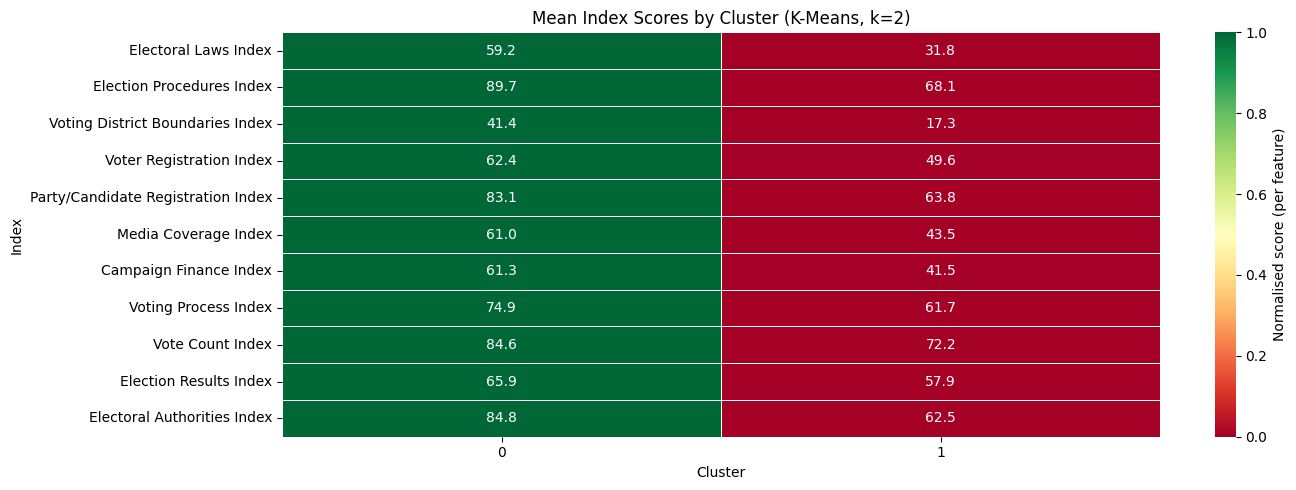

In [11]:
# Mean index heatmap

cluster_means = cluster_df.groupby('KMeans_Cluster')[index_cols].mean()

# Normalise per feature for colour only
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min() + 1e-9)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    cluster_means_norm.T,
    annot=cluster_means.T.round(1),
    fmt='.1f',
    cmap='RdYlGn',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Normalised score (per feature)'}
)
ax.set_title(f'Mean Index Scores by Cluster (K-Means, k={best_k})')
ax.set_xlabel('Cluster')
ax.set_ylabel('Index')
plt.tight_layout()
plt.show()


Cluster 0 scores higher than Cluster 1 on every index, so K-Means has essentially split the data into a higher-integrity group (Cluster 0) and a lower-integrity group (Cluster 1) rather than into qualitatively different electoral systems.

Biggest gaps are on structural/institutional indices. Electoral Laws (59.2 vs 31.8), Voting District Boundaries (41.4 vs 17.3), Electoral Authorities (84.8 vs 62.5), and Election Procedures (89.7 vs 68.1). 

Smallest gaps are on day-of-election processes. Vote Count (84.6 vs 72.2), Election Results (65.9 vs 57.9), and Voting Process (74.9 vs 61.7).

Voting District Boundaries is the weakest area in both clusters and collapses to 17.3 in Cluster 1 so is likely a defining feature of the lower-integrity group.

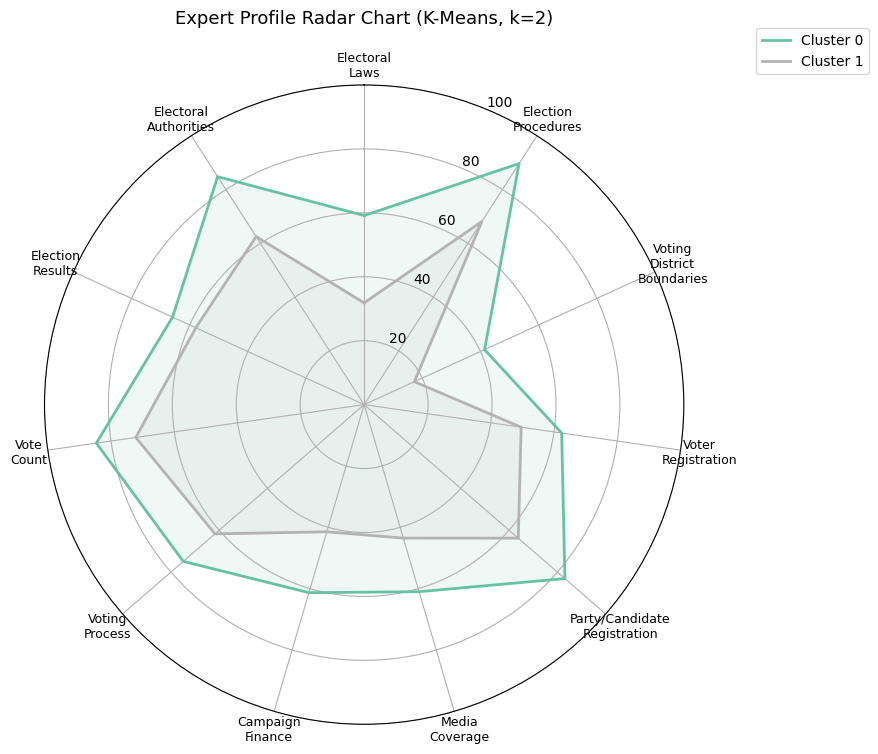

In [12]:
# Radar chart

short_names = [c.replace(' Index', '').replace(' ', '\n') for c in index_cols]
N  = len(index_cols)
angles = [n / N * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], short_names, size=9)

colors = plt.cm.Set2(np.linspace(0, 1, best_k))

for (cluster_id, row), color in zip(cluster_means.iterrows(), colors):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid',
            label=f'Cluster {cluster_id}', color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_ylim(0, 100)
ax.set_title(f'Expert Profile Radar Chart (K-Means, k={best_k})', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


The radar chart confirms what the heatmap showed. Cluster 0 sits outside Cluster 1 on every dimension with the same overall shape. The two clusters differ in size but not shape. This points to a gradient of electoral integrity rather than distinct system types.

The gap is widest on Electoral Authorities, Party/Candidate Registration, and Voting District Boundaries, and narrowest on Vote Count and Election Results where both clusters peak together. Voting District Boundaries is the lowest point for both clusters, just more severe in Cluster 1.

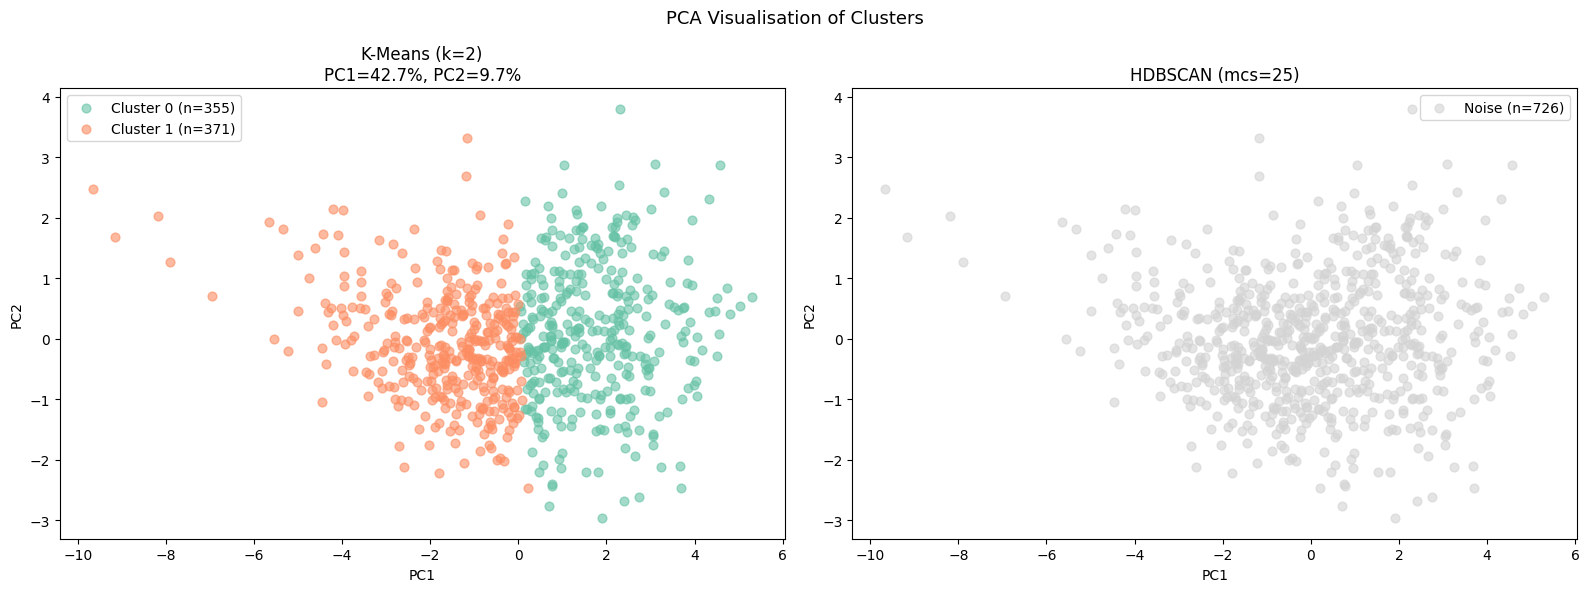

In [13]:
# PCA scatter

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X)

pca_df = pd.DataFrame({
    'PC1': pca_coords[:, 0],
    'PC2': pca_coords[:, 1],
    'KMeans': km_labels,
    'HDBSCAN': hdb_labels
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette_km = sns.color_palette('Set2', n_colors=best_k)
for cid in range(best_k):
    mask = pca_df['KMeans'] == cid
    axes[0].scatter(
        pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
        label=f'Cluster {cid} (n={mask.sum()})',
        alpha=0.6, s=40, color=palette_km[cid]
    )
axes[0].set_title(
    f'K-Means (k={best_k})\n'
    f'PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}'
)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

hdb_unique = sorted(set(hdb_labels))
hdb_real = [c for c in hdb_unique if c >= 0]
palette_hdb = sns.color_palette('Set2', n_colors=max(len(hdb_real), 1))
hdb_color_map = {cid: palette_hdb[i] for i, cid in enumerate(hdb_real)}
hdb_color_map[-1] = 'lightgrey'

for cid in hdb_unique:
    mask = pca_df['HDBSCAN'] == cid
    label = f'Cluster {cid} (n={mask.sum()})' if cid >= 0 else f'Noise (n={mask.sum()})'
    axes[1].scatter(
        pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
        label=label, alpha=0.6, s=40, color=hdb_color_map[cid]
    )
axes[1].set_title(f'HDBSCAN (mcs={best_mcs})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.suptitle('PCA Visualisation of Clusters', fontsize=13)
plt.tight_layout()
plt.show()


PC1 alone explains 42.7% of the variance and PC2 adds 9.7%, so the 2D projection captures the main structure of the data reasonably well.

K-Means (k=2) produces a clean split along PC1, with Cluster 0 (n=355) on the right and Cluster 1 (n=371) on the left. The clusters are nearly balanced and the boundary is sharp, but there's no visible gap between them. This is consistent with a gradient along PC1 rather than two genuinely separate groups.

HDBSCAN (mcs=25) classifies all 726 points as noise and finds no clusters. This reinforces the same point wher the data is one continuous cloud, not a set of dense, distinct groups. K-Means imposes a split that HDBSCAN won't.

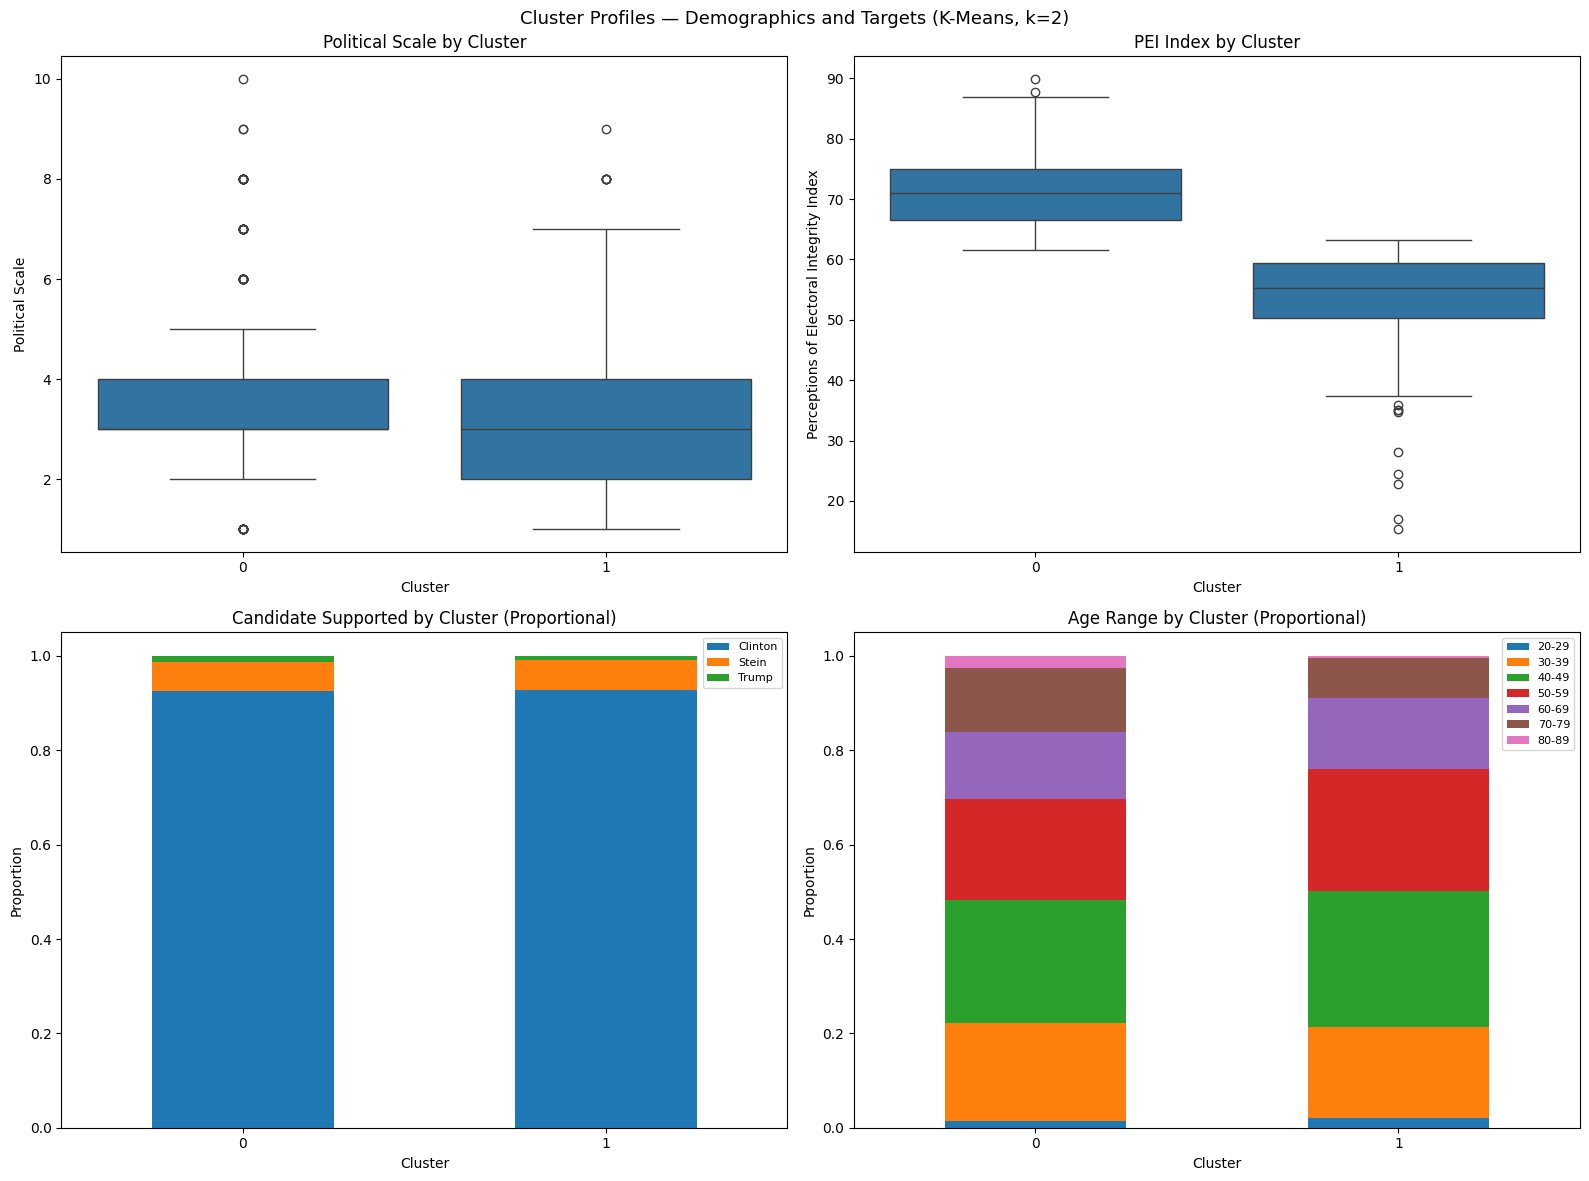

Mean Political Scale by cluster:
KMeans_Cluster
0    3.59
1    3.15
Name: Political Scale, dtype: float64

Mean PEI by cluster:
KMeans_Cluster
0    71.47
1    53.95
Name: Perceptions of Electoral Integrity Index, dtype: float64

Cluster sizes:
KMeans_Cluster
0    355
1    371
Name: count, dtype: int64


In [ ]:
# Demographic breakdown

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(x='KMeans_Cluster', y='Political Scale', data=cluster_df, ax=axes[0, 0])
axes[0, 0].set_title('Political Scale by Cluster')
axes[0, 0].set_xlabel('Cluster')

sns.boxplot(
    x='KMeans_Cluster', y='Perceptions of Electoral Integrity Index',
    data=cluster_df, ax=axes[0, 1]
)
axes[0, 1].set_title('PEI Index by Cluster')
axes[0, 1].set_xlabel('Cluster')

cand_counts = (
    cluster_df.dropna(subset=['Candidate Supported'])
    .groupby(['KMeans_Cluster', 'Candidate Supported'])
    .size()
    .unstack(fill_value=0)
)
cand_counts.div(cand_counts.sum(axis=1), axis=0).plot(
    kind='bar', ax=axes[1, 0], stacked=True
)
axes[1, 0].set_title('Candidate Supported by Cluster (Proportional)')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Proportion')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].legend(loc='upper right', fontsize=8)

age_order  = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89']
age_counts = (
    cluster_df
    .groupby(['KMeans_Cluster', 'Age Range'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[c for c in age_order if c in cluster_df['Age Range'].unique()])
)
age_counts.div(age_counts.sum(axis=1), axis=0).plot(
    kind='bar', ax=axes[1, 1], stacked=True
)
axes[1, 1].set_title('Age Range by Cluster (Proportional)')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Proportion')
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].legend(loc='upper right', fontsize=8)

plt.suptitle(f'Cluster Profiles: Demographics and Targets (K-Means, k={best_k})', fontsize=13)
plt.tight_layout()
plt.show()

print('Mean Political Scale by cluster:')
print(cluster_df.groupby('KMeans_Cluster')['Political Scale'].mean().round(2))
print('\nMean PEI by cluster:')
print(cluster_df.groupby('KMeans_Cluster')['Perceptions of Electoral Integrity Index'].mean().round(2))
print('\nCluster sizes:')
print(cluster_df['KMeans_Cluster'].value_counts().sort_index())

PEI Index is where the clusters separate most clearly: Cluster 0 has a median of roughly 71 (tight spread), Cluster 1 has a median of 55 with a long lower tail. The means (71.47 vs 53.95) confirm a  roughly 17.5-point gap. The clusters faithfully recover an overall integrity gradient, as expected since PEI summarises the 11 sub-indices used for clustering.

Political Scale, Candidate Supported, and Age Range are all nearly the same across clusters:
- Political Scale: means of 3.59 vs 3.15 
- Candidate: both roughly 93% Clinton
- Age: very similar distributions across all bands

This is the ideal pattern -> the clusters reflect what experts perceived, not who the experts are. Demographics and political leaning aren't driving the split.

## Reflection

### Methodological limitations

- Silhouette scores on high-dimensional data can understate genuine cluster structure. A uniform PCA cloud in 2D doesn't mean clusters don't exist in higher dimensions.

- K-Means assumes spherical, equal-variance clusters. If expert profiles are elongated or nested, boundary points might not be assigned properly.

- No ground truth -> silhouette and Davies-Bouldin measure internal cohesion, not whether clusters map to meaningful real-world groups.

### Analytical limitations

- This sample skews heavily left (mean Political Scale 3.36). Discovered clusters reflect sub-groups within the liberal majority rather than a clean ideological spectrum.

- Index columns are composites from the same underlying Likert items. A single dominant dimension (e.g., gerrymandering views) could overshadow more nuanced patterns.

- Bootstrap stability analysis would confirm whether cluster assignments are robust at this sample size (n=726).